Task 1: Dataset Understanding

In [48]:
import pandas as pd

df = pd.read_csv("customer_churn_nn.csv")
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [49]:
df.shape

(2000, 17)

The dataset contains 2000 rows and 17 columns.

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  discount_perce

The dataset contains numerical features such as tenure, monthly charges, total charges, and usage metrics.
It also includes categorical features such as region, plan type, contract type, and payment method.
The target variable is 'churn', which indicates whether a customer leaves the service (1) or stays (0).

In [51]:
df.isnull().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

There are no missing values in the dataset.

In [52]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


The statistical summary shows variation in numerical features such as tenure, charges, and usage, indicating diversity in customer behavior.

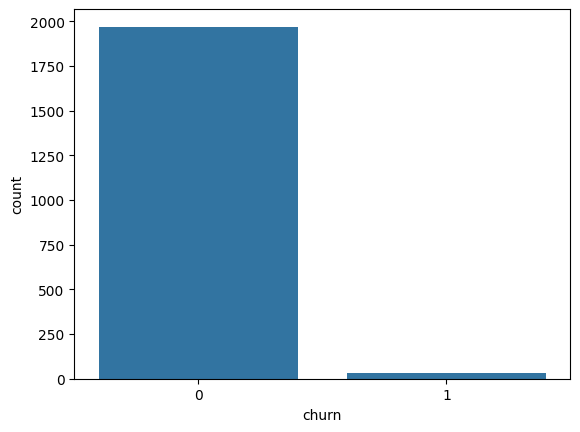

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='churn', data=df)
plt.show()

The target variable 'churn' is highly imbalanced. 
Most customers belong to the non-churn class (0), while very few belong to the churn class (1).

This imbalance may affect model performance, as the model may become biased toward predicting the majority class.

In [54]:
df.isnull().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Task 2: Data Preprocessing

In [55]:
df = df.drop('customer_id', axis=1) #dropping useless columns

In [56]:
df = pd.get_dummies(df, drop_first=True)

In [57]:
X = df.drop('churn', axis=1)
y = df['churn']

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The dataset was preprocessed before training the neural network.
-The 'customer_id' column was removed as it does not contribute to prediction.
-Categorical variables were encoded using one-hot encoding.
-The dataset was split into training and testing sets (80% training, 20% testing).
-Feature scaling was applied using StandardScaler to normalize the data.

In [60]:
print(X_train.shape)
print(X_test.shape)

(1600, 24)
(400, 24)


Task 3: Neural Network Model Building

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [62]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\milir\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [64]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

Task 4: Training and Evaluation

In [65]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.6488 - loss: 0.6197 - val_accuracy: 0.9750 - val_loss: 0.3325
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9850 - loss: 0.2028 - val_accuracy: 0.9825 - val_loss: 0.1430
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9850 - loss: 0.1080 - val_accuracy: 0.9825 - val_loss: 0.1019
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9850 - loss: 0.0855 - val_accuracy: 0.9825 - val_loss: 0.0901
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9850 - loss: 0.0771 - val_accuracy: 0.9825 - val_loss: 0.0861
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9850 - loss: 0.0722 - val_accuracy: 0.9825 - val_loss: 0.0839
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9850 - loss: 0.0686 - val_accuracy: 0.9825 - val_loss: 0.0828
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9850 - loss: 0.0661 - val_accuracy: 0.9825 - val

In [66]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9825 - loss: 0.0770
Test Accuracy: 0.9825000166893005


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


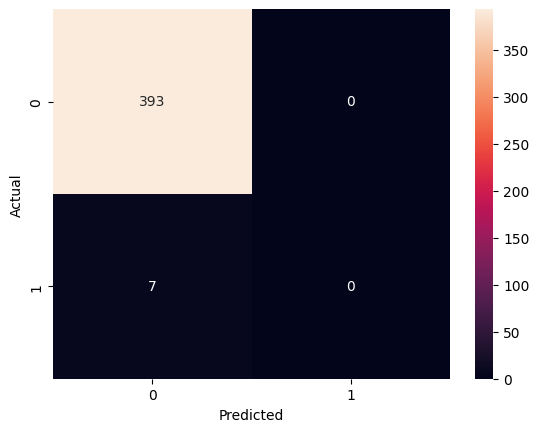

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Although the model achieved very high accuracy (~98%), the confusion matrix reveals that it fails to predict any churn cases.
The model predicts all customers as non-churn (class 0), resulting in zero true positives.
This happens due to severe class imbalance in the dataset, where the majority of samples belong to the non-churn class.
Therefore, accuracy is not a reliable metric in this case.

Task 5: Hyperparameter Experimentation

EXPERIMENT 1 (BASELINE)

In [68]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.5076142131979695), 1: np.float64(33.333333333333336)}


In [69]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9669 - loss: 0.6382 - val_accuracy: 0.8950 - val_loss: 0.2493
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8475 - loss: 0.3349 - val_accuracy: 0.8800 - val_loss: 0.2742
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9031 - loss: 0.2748 - val_accuracy: 0.9000 - val_loss: 0.2483
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9019 - loss: 0.2339 - val_accuracy: 0.9100 - val_loss: 0.2335
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9044 - loss: 0.1995 - val_accuracy: 0.9300 - val_loss: 0.2031
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9344 - loss: 0.1769 - val_accuracy: 0.9300 - val_loss: 0.1994
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9306 - loss: 0.1549 - val_accuracy: 0.9425 - val_loss: 0.1768
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9538 - loss: 0.1394 - val_accuracy: 0.9375 - v

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


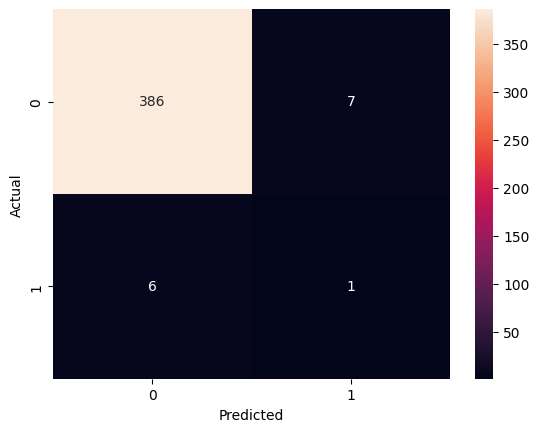

In [70]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
loss, accuracy = model.evaluate(X_test, y_test)
print(accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9675 - loss: 0.1144
0.9674999713897705


After applying class weights, the model improved its ability to detect churn cases.
Earlier, the model predicted only the majority class and failed to identify any churn customers.
With class weighting, the model correctly identified some churn cases, although overall accuracy slightly decreased.
This demonstrates that handling class imbalance improves the model’s practical usefulness, even if accuracy is reduced.

EXPERIMENT 2: MORE NEURONS

In [72]:
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))  # increased
model.add(Dense(32, activation='relu'))  # increased
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\milir\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [73]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8981 - loss: 0.6291 - val_accuracy: 0.8700 - val_loss: 0.4625
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8219 - loss: 0.5051 - val_accuracy: 0.8700 - val_loss: 0.4289
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8281 - loss: 0.4419 - val_accuracy: 0.8525 - val_loss: 0.4059
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8500 - loss: 0.3903 - val_accuracy: 0.8875 - val_loss: 0.3448
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8869 - loss: 0.3356 - val_accuracy: 0.8725 - val_loss: 0.3269
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8687 - loss: 0.2923 - val_accuracy: 0.8975 - val_loss: 0.2762
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8875 - loss: 0.2520 - val_accuracy: 0.8900 - val_loss: 0.2790
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9119 - loss: 0.2207 - val_accuracy: 0.8925 - v

In [74]:
loss, acc2 = model.evaluate(X_test, y_test)
print(acc2)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9500 - loss: 0.1223
0.949999988079071


EXPERIMENT 3: MORE EPOCHS

In [75]:
history = model.fit(
    X_train, y_train,
    epochs=30,  # increased
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9762 - loss: 0.0549 - val_accuracy: 0.9625 - val_loss: 0.1103
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9787 - loss: 0.0505 - val_accuracy: 0.9650 - val_loss: 0.1060
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9781 - loss: 0.0464 - val_accuracy: 0.9650 - val_loss: 0.1119
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9819 - loss: 0.0415 - val_accuracy: 0.9650 - val_loss: 0.0975
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9844 - loss: 0.0395 - val_accuracy: 0.9675 - val_loss: 0.1048
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9850 - loss: 0.0361 - val_accuracy: 0.9650 - val_loss: 0.1066
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9850 - loss: 0.0335 - val_accuracy: 0.9650 - val_loss: 0.1089
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9869 - loss: 0.0304 - val_accuracy: 0.9675 - va

In [76]:
loss, acc3 = model.evaluate(X_test, y_test)
print(acc3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9700 - loss: 0.1274  
0.9700000286102295


In [77]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": ["Baseline", "More Neurons", "More Epochs"],
    "Accuracy": [accuracy, acc2, acc3]
})

results

,Experiment,Accuracy
0,Baseline,0.9675
1,More Neurons,0.9500
2,More Epochs,0.9700


In [78]:
import os
os.makedirs("results", exist_ok=True)

In [79]:
results.to_csv("results/model_comparison.csv", index=False)

Task 6: Final Reflection
1. Role of Weights and Biases
Weights determine the importance of each input feature in the model, while biases allow the model to adjust the output. Together, they help the neural network learn patterns from the data.

2. Why Activation Function is Required
Activation functions introduce non-linearity into the model. Without them, the neural network would behave like a simple linear model and would not be able to learn complex relationships.

3. Learning Rate Impact
If the learning rate is too high, the model may overshoot optimal values and fail to learn properly. If it is too low, the training process becomes very slow and may get stuck.

4. Underfitting vs Overfitting
The initial model showed signs of underfitting for the minority class (churn), as it failed to predict any churn cases. After handling class imbalance, the model improved its ability to generalize, although some misclassification still exists.